# IBM topic sentiment — complete primary-model analysis

        This notebook uses only fields produced by the IBM sentiment experiment:
        gold topic sentiment, model predictions and candidate probabilities,
        assigned persona, and randomized prompt factors. It contains the paper's
        four Gemma 3 IT and four Qwen3 checkpoints.

        The exploratory LLM-authored target taxonomy and its downstream figures
        are deliberately excluded. They are not needed to reproduce the paper's
        core sentiment diagnostics and would add an unvalidated annotation layer.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

ANALYSIS=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
if not (ANALYSIS/'data').exists(): ANALYSIS=Path.cwd()/'tasks'/'sentiment'/'analysis'
DATA=ANALYSIS/'data'; FIGURES=ANALYSIS/'figures'
coverage=pd.read_csv(DATA/'coverage_by_model.csv')
summary_model=pd.read_csv(DATA/'summary_by_model.csv')
summary_persona=pd.read_csv(DATA/'summary_by_model_persona.csv')
sensitivity=pd.read_csv(DATA/'factor_sensitivity_macro_f1.csv')
config=pd.read_csv(DATA/'config_level_metrics.csv')
topics=pd.read_csv(DATA/'topic_descriptive_metrics.csv')
model_order=['gemma-3-1b-it','gemma-3-4b-it','gemma-3-12b-it','gemma-3-27b-it',
             'Qwen3-4B','Qwen3-8B','Qwen3-14B','Qwen3-32B']
ideology_order=['base','centrism','libertarian_left','libertarian_right',
                'authoritarian_left','authoritarian_right']
sns.set_theme(style='whitegrid')

## Coverage and label support

        Each model has 1,800 configurations × 30 topics = 54,000 predictions.
        Coverage is checked before any comparison. The topic table also makes
        the single gold label per topic explicit; per-topic macro-F1 would be
        inappropriate because each topic supplies only one class.

In [2]:
display(coverage)
support=topics.drop_duplicates('item_index').groupby('gold_label').size().rename('topics')
display(support.to_frame())
assert coverage.coverage.eq(1).all() and coverage.error_rows.eq(0).all()
assert coverage.successful_rows.sum()==432_000
assert len(topics)==8*6*30

,model,successful_rows,error_rows,unique_configs,unique_items,expected_rows,coverage,path_exists
0,gemma-3-1b-it,54000,0,1800,30,54000,1.0,True
1,gemma-3-4b-it,54000,0,1800,30,54000,1.0,True
2,gemma-3-12b-it,54000,0,1800,30,54000,1.0,True
3,gemma-3-27b-it,54000,0,1800,30,54000,1.0,True
4,Qwen3-4B,54000,0,1800,30,54000,1.0,True
5,Qwen3-8B,54000,0,1800,30,54000,1.0,True
6,Qwen3-14B,54000,0,1800,30,54000,1.0,True
7,Qwen3-32B,54000,0,1800,30,54000,1.0,True


,topics
gold_label,
NEGATIVE,11
POSITIVE,19


## Overall and assigned-persona performance

        Macro-F1 gives equal weight to positive and negative labels. The overall
        table pools all persona conditions. Every heatmap cell pools 9,000
        predictions (300 configurations × 30 topics). Persona names denote the
        assigned prompt condition, not a model's intrinsic ideology.

,model,n,accuracy,macro_f1,negative_f1,positive_f1,mean_confidence,positive_pred_rate
0,gemma-3-1b-it,54000,0.523556,0.512033,0.437049,0.587017,0.891852,0.520333
1,gemma-3-4b-it,54000,0.532815,0.532809,0.531200,0.534418,0.897880,0.370111
2,gemma-3-12b-it,54000,0.562500,0.561306,0.538421,0.584191,0.915267,0.418833
3,gemma-3-27b-it,54000,0.550000,0.549623,0.562651,0.536596,0.947371,0.337741
4,Qwen3-4B,54000,0.579630,0.573188,0.520753,0.625623,0.836182,0.489519
5,Qwen3-8B,54000,0.590370,0.579017,0.509882,0.648152,0.803780,0.530889
6,Qwen3-14B,54000,0.583759,0.581151,0.548101,0.614202,0.830239,0.445574
7,Qwen3-32B,54000,0.585130,0.579665,0.531739,0.627591,0.785061,0.480685


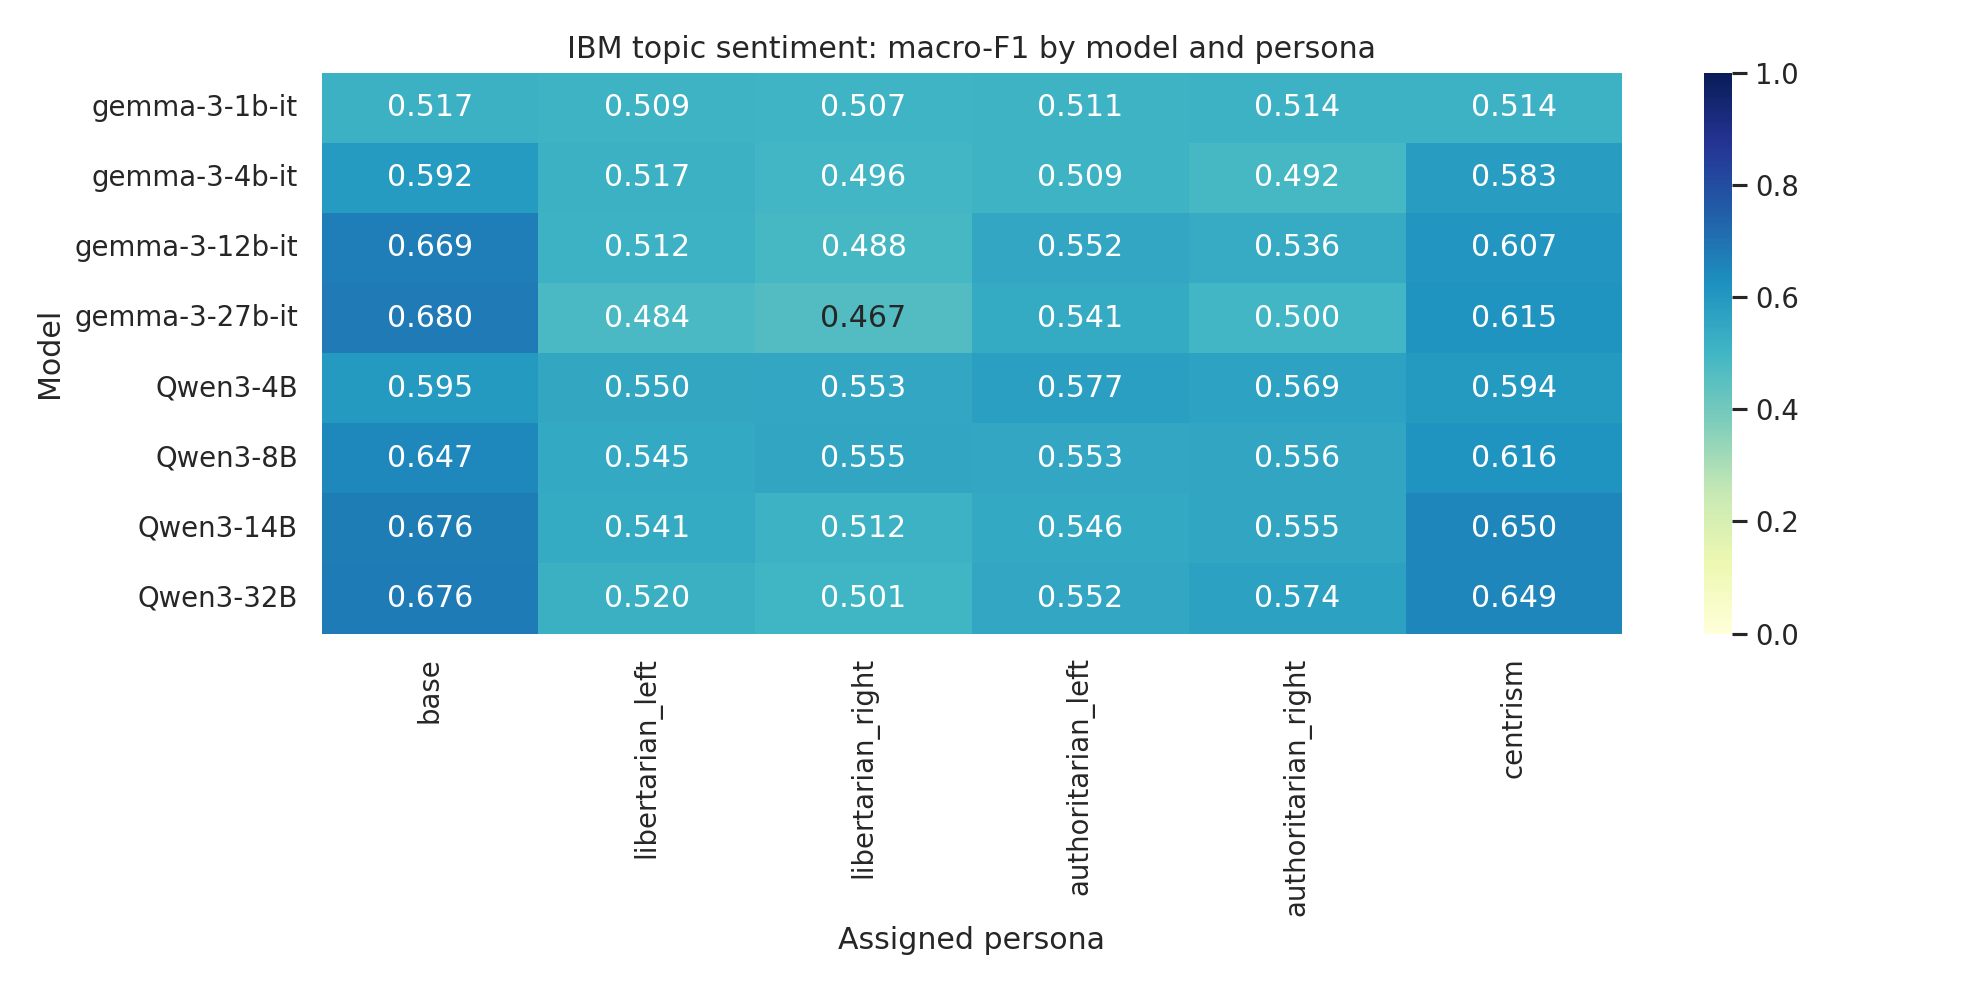

In [3]:
display(summary_model[['model','n','accuracy','macro_f1','negative_f1','positive_f1',
                       'mean_confidence','positive_pred_rate']])
display(Image(filename=str(FIGURES/'ibm_sentiment_macro_f1_model_persona_heatmap.png')))

## Persona deltas from the base condition

        Subtracting each model's base macro-F1 makes robustness loss or gain
        visible without adding a topic taxonomy. Negative values mean lower
        macro-F1 under that assigned persona in this experiment.

ideology,authoritarian_left,authoritarian_right,centrism,libertarian_left,libertarian_right
model,,,,,
gemma-3-1b-it,-0.006,-0.004,-0.003,-0.008,-0.010
gemma-3-4b-it,-0.083,-0.100,-0.009,-0.075,-0.096
gemma-3-12b-it,-0.117,-0.133,-0.062,-0.157,-0.181
gemma-3-27b-it,-0.139,-0.181,-0.066,-0.196,-0.213
Qwen3-4B,-0.018,-0.026,-0.001,-0.045,-0.042
Qwen3-8B,-0.094,-0.091,-0.031,-0.102,-0.092
Qwen3-14B,-0.130,-0.121,-0.026,-0.135,-0.164
Qwen3-32B,-0.124,-0.102,-0.028,-0.156,-0.176


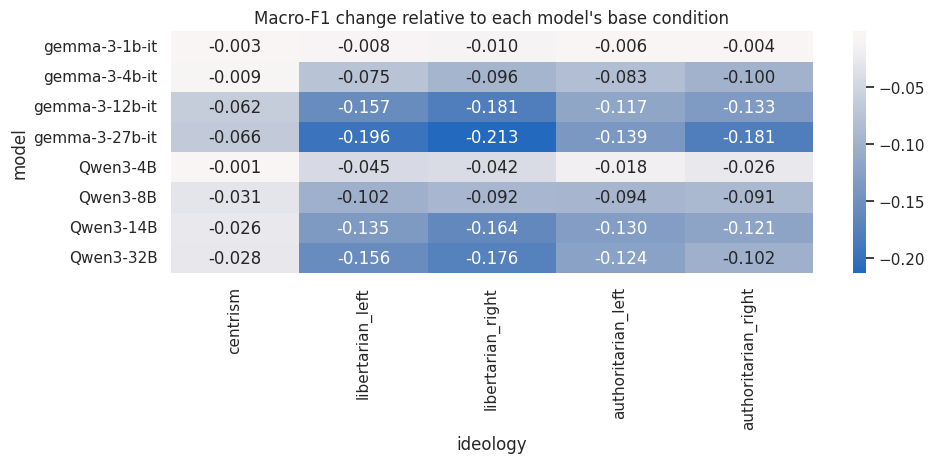

In [4]:
wide=summary_persona.pivot(index='model',columns='ideology',values='macro_f1').reindex(model_order)
delta=wide.subtract(wide['base'],axis=0).drop(columns='base')
display(delta.round(3))
fig,ax=plt.subplots(figsize=(10,4.8))
sns.heatmap(delta.reindex(columns=[x for x in ideology_order if x!='base']),annot=True,fmt='.3f',
            center=0,cmap='vlag',ax=ax)
ax.set_title("Macro-F1 change relative to each model's base condition")
fig.tight_layout(); plt.show()

## Configuration-level distributions

        Means can hide unstable configurations. The boxplots show the full
        distribution of configuration-level macro-F1. Each configuration
        contains all 30 topics.

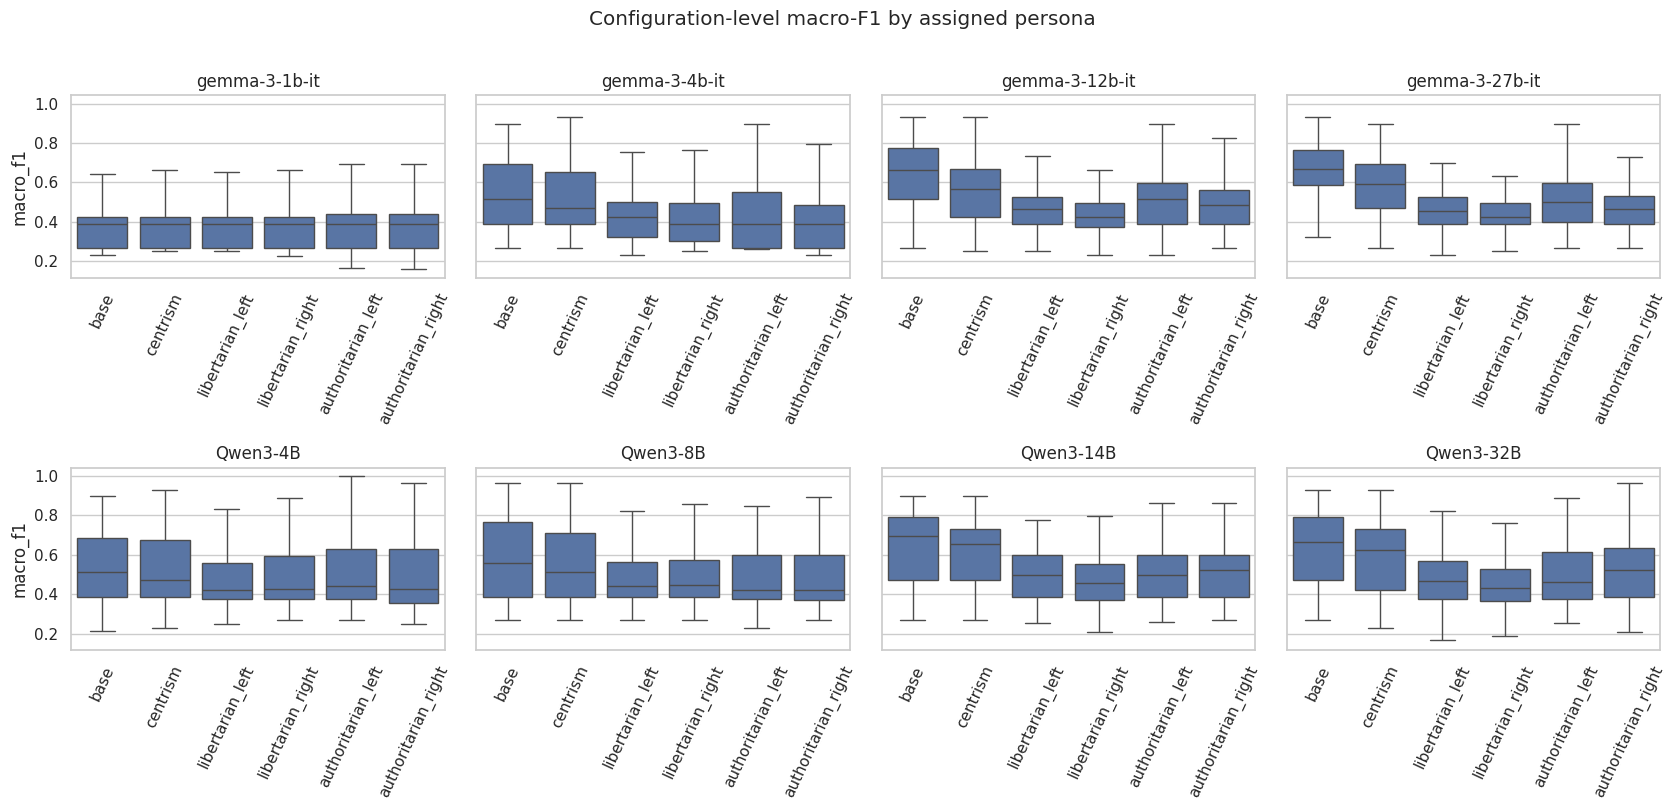

In [5]:
fig,axes=plt.subplots(2,4,figsize=(17,8),sharey=True)
for ax,model in zip(axes.flat,model_order):
    sub=config[config.model.eq(model)]
    sns.boxplot(data=sub,x='ideology',y='macro_f1',order=ideology_order,showfliers=False,ax=ax)
    ax.set_title(model); ax.tick_params(axis='x',rotation=65); ax.set_xlabel('')
fig.suptitle('Configuration-level macro-F1 by assigned persona',y=1.01)
fig.tight_layout(); plt.show()

## Prompt-factor sensitivity

        Each named factor is a descriptive root-mean-square spread in
        configuration macro-F1 between factor levels, calculated within persona
        conditions. `Ideology SD` is the spread of persona-condition means;
        `Residual RMSE` comes from an additive dummy-coded model. Components are
        not causal and do not add up to total variance.

,model,metric,Ideology SD,Total Var SD,Residual RMSE,Context,Instruction,Key Type,Permutation,Persona
0,gemma-3-1b-it,macro_f1,0.003,0.122,0.106,0.019,0.030,0.033,0.034,0.027
1,gemma-3-4b-it,macro_f1,0.052,0.160,0.140,0.026,0.059,0.018,0.027,0.038
2,gemma-3-12b-it,macro_f1,0.071,0.151,0.128,0.043,0.045,0.027,0.025,0.032
3,gemma-3-27b-it,macro_f1,0.085,0.147,0.114,0.034,0.059,0.013,0.029,0.032
4,Qwen3-4B,macro_f1,0.022,0.174,0.147,0.028,0.066,0.046,0.038,0.032
5,Qwen3-8B,macro_f1,0.046,0.174,0.136,0.056,0.087,0.025,0.025,0.032
6,Qwen3-14B,macro_f1,0.068,0.164,0.130,0.045,0.080,0.038,0.023,0.026
7,Qwen3-32B,macro_f1,0.070,0.173,0.122,0.071,0.090,0.044,0.015,0.034


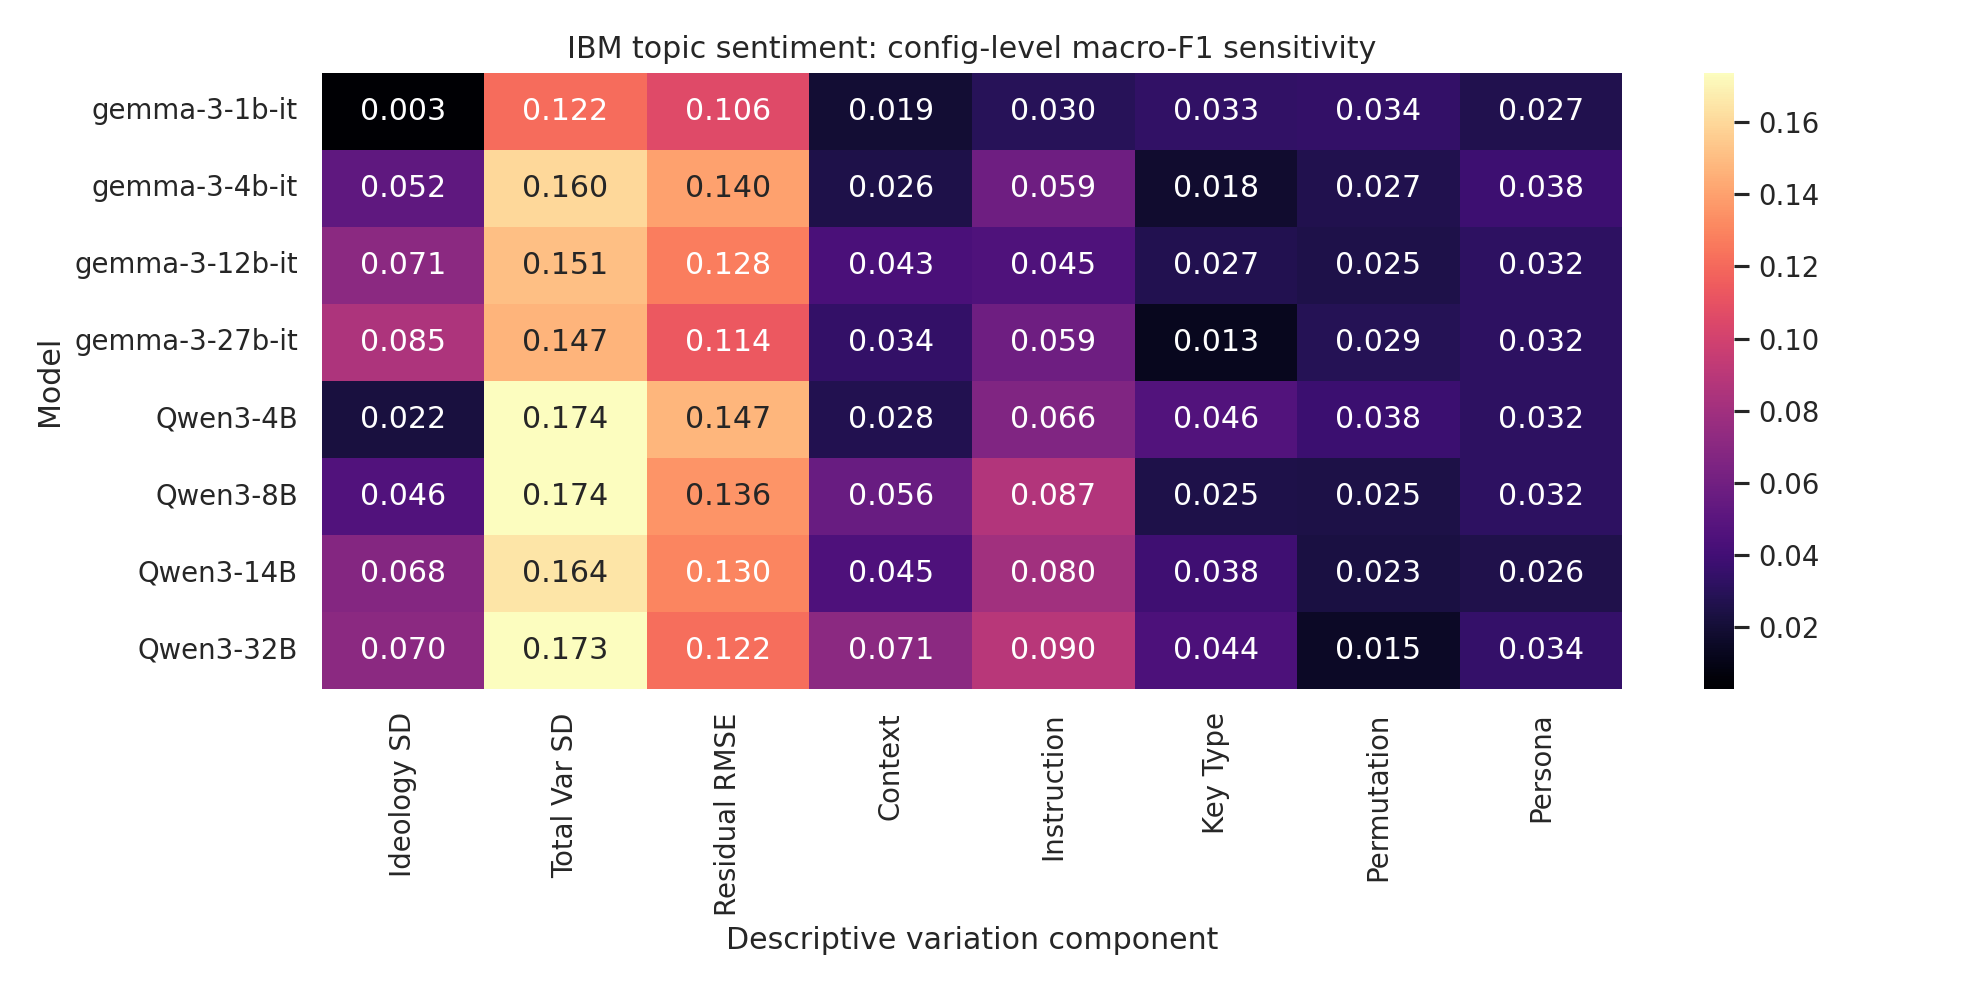

,largest named factor,SD-sized magnitude
model,,
gemma-3-1b-it,Permutation,0.033915
gemma-3-4b-it,Instruction,0.058996
gemma-3-12b-it,Instruction,0.045225
gemma-3-27b-it,Instruction,0.059023
Qwen3-4B,Instruction,0.065768
Qwen3-8B,Instruction,0.086644
Qwen3-14B,Instruction,0.080033
Qwen3-32B,Instruction,0.089666


In [6]:
display(sensitivity.round(3))
display(Image(filename=str(FIGURES/'ibm_sentiment_factor_sensitivity_macro_f1.png')))
named=['Context','Instruction','Key Type','Permutation','Persona']
largest=sensitivity.set_index('model')[named].idxmax(axis=1).rename('largest named factor')
display(largest.to_frame().join(sensitivity.set_index('model')[named].max(axis=1).rename('SD-sized magnitude')))

## Topic-level descriptive diagnostics

        For each model × persona × topic, the table reports accuracy, positive
        prediction rate and confidence over 300 randomized prompt
        configurations. The largest within-topic persona ranges locate fragile
        topics without claiming a universal political direction.

In [7]:
topic_range=(topics.groupby(['model','item_index','topic','gold_label'],observed=True)
             .agg(min_accuracy=('accuracy','min'),max_accuracy=('accuracy','max'),
                  min_positive_rate=('positive_pred_rate','min'),max_positive_rate=('positive_pred_rate','max'))
             .reset_index())
topic_range['accuracy_range']=topic_range.max_accuracy-topic_range.min_accuracy
topic_range['positive_rate_range']=topic_range.max_positive_rate-topic_range.min_positive_rate
display(topic_range.sort_values('accuracy_range',ascending=False).head(20))

,model,item_index,topic,gold_label,min_accuracy,max_accuracy,min_positive_rate,max_positive_rate,accuracy_range,positive_rate_range
186,gemma-3-27b-it,6,This house would embrace multiculturalism,POSITIVE,0.060000,0.943333,0.060000,0.943333,0.883333,0.883333
208,gemma-3-27b-it,28,This house would encourage the creation of pri...,POSITIVE,0.070000,0.940000,0.070000,0.940000,0.870000,0.870000
206,gemma-3-27b-it,26,This house would build the Keystone XL pipeline,POSITIVE,0.070000,0.930000,0.070000,0.930000,0.860000,0.860000
193,gemma-3-27b-it,13,This house would subsidize poor communities,POSITIVE,0.066667,0.923333,0.066667,0.923333,0.856667,0.856667
126,gemma-3-12b-it,6,This house would embrace multiculturalism,POSITIVE,0.116667,0.933333,0.116667,0.933333,0.816667,0.816667
198,gemma-3-27b-it,18,This house believes that housewives should be ...,POSITIVE,0.113333,0.910000,0.113333,0.910000,0.796667,0.796667
148,gemma-3-12b-it,28,This house would encourage the creation of pri...,POSITIVE,0.123333,0.913333,0.123333,0.913333,0.790000,0.790000
196,gemma-3-27b-it,16,This house believes that democratic government...,POSITIVE,0.060000,0.846667,0.060000,0.846667,0.786667,0.786667
28,Qwen3-14B,28,This house would encourage the creation of pri...,POSITIVE,0.130000,0.903333,0.130000,0.903333,0.773333,0.773333
200,gemma-3-27b-it,20,This house believes that wind power should be ...,POSITIVE,0.173333,0.943333,0.173333,0.943333,0.770000,0.770000


## Prediction-skew diagnostics

        Accuracy does not reveal how errors move. `positive_pred_rate −
        positive_gold_rate` is positive when a condition over-predicts positive
        sentiment and negative when it under-predicts it.

In [8]:
skew=(config.groupby(['model','ideology'],observed=True)
      .agg(accuracy=('accuracy','mean'),macro_f1=('macro_f1','mean'),
           positive_pred_rate=('positive_pred_rate','mean'),
           positive_gold_rate=('positive_gold_rate','mean')).reset_index())
skew['positive_prediction_skew']=skew.positive_pred_rate-skew.positive_gold_rate
display(skew.pivot(index='model',columns='ideology',values='positive_prediction_skew')
        .reindex(model_order).reindex(columns=ideology_order).round(3))

ideology,base,centrism,libertarian_left,libertarian_right,authoritarian_left,authoritarian_right
model,,,,,,
gemma-3-1b-it,-0.105,-0.091,-0.110,-0.120,-0.124,-0.129
gemma-3-4b-it,-0.236,-0.167,-0.244,-0.285,-0.311,-0.336
gemma-3-12b-it,-0.186,-0.183,-0.218,-0.283,-0.167,-0.250
gemma-3-27b-it,-0.211,-0.244,-0.309,-0.387,-0.269,-0.354
Qwen3-4B,-0.149,-0.111,-0.143,-0.147,-0.151,-0.161
Qwen3-8B,-0.077,-0.049,-0.102,-0.151,-0.085,-0.150
Qwen3-14B,-0.125,-0.138,-0.145,-0.288,-0.171,-0.259
Qwen3-32B,-0.095,-0.093,-0.168,-0.273,-0.101,-0.185


## Model and size summaries

        Family/size tables are descriptive only. Four checkpoints per family
        are insufficient to infer a general scaling law, and prompt sensitivity
        is not monotonic across all conditions.

In [9]:
model_summary=summary_model.set_index('model').reindex(model_order).copy()
model_summary['family']=['Gemma 3']*4+['Qwen3']*4
model_summary['size_b']=[1,4,12,27,4,8,14,32]
display(model_summary[['family','size_b','accuracy','macro_f1','mean_confidence','positive_pred_rate']])

,family,size_b,accuracy,macro_f1,mean_confidence,positive_pred_rate
model,,,,,,
gemma-3-1b-it,Gemma 3,1,0.523556,0.512033,0.891852,0.520333
gemma-3-4b-it,Gemma 3,4,0.532815,0.532809,0.897880,0.370111
gemma-3-12b-it,Gemma 3,12,0.562500,0.561306,0.915267,0.418833
gemma-3-27b-it,Gemma 3,27,0.550000,0.549623,0.947371,0.337741
Qwen3-4B,Qwen3,4,0.579630,0.573188,0.836182,0.489519
Qwen3-8B,Qwen3,8,0.590370,0.579017,0.803780,0.530889
Qwen3-14B,Qwen3,14,0.583759,0.581151,0.830239,0.445574
Qwen3-32B,Qwen3,32,0.585130,0.579665,0.785061,0.480685


## Interpretation boundary

        The defensible result is that IBM topic-sentiment performance and
        positive/negative prediction balance vary across assigned personas and
        prompt factors, with checkpoint-specific magnitudes. This notebook does
        not use LLM-authored target labels, does not establish an intrinsic
        political sentiment tendency, and does not support a universal family
        or size effect.